In [1]:
! pip install numpy
! pip install matplotlib
! pip install pandas


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [3]:
# read science data line by line, parse json, and store in a list
# filename = 'batch_20240411_1440_MITMBA.scienceData.jsonl'
# filename = 'batch_20240416_1753_MITMBA.scienceData.jsonl'
filenames = [
    # "batch_20250317_1538_pilotA.scienceData.jsonl",
   "batch_20250618_1821_pilot.scienceData.jsonl",
   "batch_20250708_1813_pilot.scienceData.jsonl"
]
data = []
for filename in filenames:
    with open(filename) as f:
        for line in f:
            parsed = json.loads(line)
            if parsed['sampleId'] != 'missing':
                data.append(parsed)

sorted_data = sorted(data, key=lambda x: x['treatment']['name']+x['gameId'])

new_data = []
game_lookups = {}
game_index = 0
for i, row in enumerate(sorted_data):
    row["player"] = i
    if row["gameId"] not in game_lookups:
        game_lookups[row["gameId"]] = game_index
        row["game"] = game_index
        game_index += 1
    else:
        row["game"] = game_lookups[row["gameId"]]

    new_data.append(row)

data = new_data
index = pd.MultiIndex.from_tuples([(row['treatment']["name"], row['gameId'][-6:], row['position']) for row in data], names=['treatment', 'game', 'player'])
len(data)

32

In [4]:
print(list(data[0].keys()))

['containerTag', 'deliberationId', 'sampleId', 'browserInfo', 'connectionInfo', 'batchId', 'config', 'times', 'consent', 'introSequence', 'gameId', 'treatment', 'position', 'recordingsFolder', 'recordingRoomName', 'recordingsPath', 'recordingIds', 'surveys', 'prompts', 'qualtrics', 'stageSubmissions', 'stageDurations', 'QCSurvey', 'exitStatus', 'connectionHistory', 'speakerEvents', 'reports', 'checkIns', 'textChats', 'cumulativeSpeakingTime', 'exportErrors', 'player', 'game']


In [5]:
treatments = pd.DataFrame([row["treatment"]["name"] for row in data], columns=["treatment"], index=index)
treatments

treatment
treatment game   player           
nonschema 63E4P3 0       nonschema
                 1       nonschema
          DM261K 0       nonschema
                 1       nonschema
          34BR1P 1       nonschema
                 0       nonschema
          XX6T5Y 0       nonschema
                 1       nonschema
          VQP5V1 0       nonschema
                 1       nonschema
          FTM1KT 1       nonschema
                 0       nonschema
          Q6ZARX 1       nonschema
                 0       nonschema
          2XT15E 1       nonschema
                 0       nonschema
schema    RTYG0G 1          schema
                 0          schema
          RFMEFG 0          schema
                 1          schema
          Y15NND 1          schema
                 0          schema
          TKB9T5 1          schema
                 0          schema
          AYS7KJ 1          schema
                 0          schema
          ZN46AE 0          schema
                 1          schema
          TD1HQA 0          schema
                 1          schema
          2BY1T9 0          schema
                 1          schema

In [6]:
connection_info = pd.DataFrame([row['connectionInfo'] for row in data], index=index)
connection_info

country                      timezone  isKnownVpn  \
treatment game   player                                                     
nonschema 63E4P3 0           US              America/New_York       False   
                 1           US              America/New_York       False   
          DM261K 0           US              America/New_York       False   
                 1           US           America/Los_Angeles       False   
          34BR1P 1           US              America/New_York       False   
                 0           US              America/New_York       False   
          XX6T5Y 0           US              America/New_York       False   
                 1           US              America/New_York       False   
          VQP5V1 0           US           America/Los_Angeles       False   
                 1           US              America/New_York       False   
          FTM1KT 1           US                America/Denver       False   
                 0           US           America/Los_Angeles       False   
          Q6ZARX 1           US           America/Los_Angeles       False   
                 0           US           America/Los_Angeles       False   
          2XT15E 1           US              America/New_York       False   
                 0           US              America/New_York       False   
schema    RTYG0G 1           US              America/New_York       False   
                 0           US           America/Los_Angeles       False   
          RFMEFG 0           US              America/New_York       False   
                 1           US              America/New_York       False   
          Y15NND 1           US              America/New_York       False   
                 0           US              America/New_York       False   
          TKB9T5 1           US           America/Los_Angeles       False   
                 0           US              America/New_York       False   
          AYS7KJ 1           US           America/Los_Angeles       False   
                 0           US           America/Los_Angeles       False   
          ZN46AE 0           US               America/Chicago       False   
                 1           US           America/Los_Angeles       False   
          TD1HQA 0           US              America/New_York       False   
                 1           US              America/New_York       False   
          2BY1T9 0           US              America/New_York       False   
                 1           US  America/Indiana/Indianapolis       False   

                        timezoneOffset  isLikelyVpn effectiveType saveData  \
treatment game   player                                                      
nonschema 63E4P3 0              -04:00        False            4g    False   
                 1              -04:00        False            4g    False   
          DM261K 0              -04:00        False            4g    False   
                 1              -07:00        False           NaN      NaN   
          34BR1P 1              -04:00        False            4g    False   
                 0              -04:00        False            4g    False   
          XX6T5Y 0              -04:00        False            4g    False   
                 1              -04:00        False            4g    False   
          VQP5V1 0              -07:00         True            4g    False   
                 1              -04:00         True            4g    False   
          FTM1KT 1              -06:00        False            4g    False   
                 0              -07:00        False            4g    False   
          Q6ZARX 1              -07:00        False            4g    False   
                 0              -07:00         True            4g    False   
          2XT15E 1              -04:00        False           NaN      NaN   
                 0              -04:00        False            4g    False   
s

In [7]:
browser_info = pd.DataFrame([row['browserInfo'] for row in data], index=index)
browser_info

screenWidth  screenHeight  width  height  \
treatment game   player                                             
nonschema 63E4P3 0              2560          1032   1278     910   
                 1              1366           720   1358     612   
          DM261K 0              1536           816   1528     738   
                 1              1728          1009   1402     923   
          34BR1P 1              1366           720   1366     649   
                 0              1366           768   1366     681   
          XX6T5Y 0              1300           682   1300     561   
                 1              1778          1067   1779     946   
          VQP5V1 0              1600           860   1600     773   
                 1              1152           644   1144     523   
          FTM1KT 1              1920          1032   1920     945   
                 0              2506          1415   1317     934   
          Q6ZARX 1              3440          1352   3440    1265   
                 0              1366           720   1366     633   
          2XT15E 1              1920          1032   1920     919   
                 0              2056          1285   1912     993   
schema    RTYG0G 1              1366           720   1366     633   
                 0              1536           816   1536     730   
          RFMEFG 0              1792          1010   1770     919   
                 1              1600           860   1601     773   
          Y15NND 1              1920          1032   1139     910   
                 0              1366           720   1366     599   
          TKB9T5 1              1536           816   1536     695   
                 0              1536           824   1920     879   
          AYS7KJ 1              1920          1050   1193    1024   
                 0              1093           615   1215     585   
          ZN46AE 0              1680          1050   1680     962   
                 1              1536           816   1536     730   
          TD1HQA 0              1536           816   1536     695   
                 1              1920          1032   1920     911   
          2BY1T9 0              1280           752   1280     639   
                 1              2560          1440   2560    1355   

                                                                 userAgent  \
treatment game   player                                                      
nonschema 63E4P3 0       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
                 1       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          DM261K 0       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
                 1       Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; ...   
          34BR1P 1       Mozilla/5.0 (X11; CrOS x86_64 14092.77.0) Appl...   
                 0       Mozilla/5.0 (X11; CrOS x86_64 14541.0.0) Apple...   
          XX6T5Y 0       Mozilla/5.0 (X11; CrOS x86_64 14541.0.0) Apple...   
                 1       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          VQP5V1 0       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
                 1       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          FTM1KT 1       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
                 0       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          Q6ZARX 1       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
                 0       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          2XT15E 1       Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
                 0       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
schema    RTYG0G 1       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
                 0       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          RFMEFG 0       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
                 1       Mozilla/5.0 (Wi

In [8]:
QC = pd.DataFrame([(row['QCSurvey']['responses'] if row['QCSurvey'] != "missing" else {}) for row in data], index=index)
QC

participateAgain adequateCompensation adequateTime  \
treatment game   player                                                      
nonschema 63E4P3 0                   yes          fairly_paid     adequate   
                 1                   yes          fairly_paid   too_little   
          DM261K 0                   yes          fairly_paid     adequate   
                 1                   yes          fairly_paid   too_little   
          34BR1P 1                   yes          fairly_paid     adequate   
                 0                   yes          fairly_paid     adequate   
          XX6T5Y 0                   yes          fairly_paid     adequate   
                 1                   yes          fairly_paid     adequate   
          VQP5V1 0                   yes          fairly_paid   too_little   
                 1                   NaN                  NaN          NaN   
          FTM1KT 1                   NaN                  NaN          NaN   
                 0                   yes          fairly_paid     adequate   
          Q6ZARX 1                   yes          fairly_paid     adequate   
                 0                   yes          fairly_paid   too_little   
          2XT15E 1                   yes          fairly_paid     adequate   
                 0                   yes          fairly_paid   too_little   
schema    RTYG0G 1                   NaN                  NaN          NaN   
                 0                   yes          fairly_paid     adequate   
          RFMEFG 0                   yes            underpaid     adequate   
                 1                   yes          fairly_paid     adequate   
          Y15NND 1                   yes          fairly_paid     adequate   
                 0                   yes          fairly_paid     adequate   
          TKB9T5 1                   yes            underpaid     adequate   
                 0                   yes          fairly_paid     adequate   
          AYS7KJ 1                   yes          fairly_paid     adequate   
                 0                   yes          fairly_paid     adequate   
          ZN46AE 0                   yes          fairly_paid     adequate   
                 1                   NaN                  NaN          NaN   
          TD1HQA 0                   yes          fairly_paid   too_little   
                 1                   yes          fairly_paid     adequate   
          2BY1T9 0                   NaN                  NaN          NaN   
                 1                   yes          fairly_paid     adequate   

                         clearInstructions  videoQuality joiningProblems  \
treatment game   player                                                    
nonschema 63E4P3 0                     5.0           4.0              no   
                 1                     4.0           5.0              no   
          DM261K 0                     4.0           5.0              no   
                 1                     4.0           4.0              no   
          34BR1P 1                     5.0           5.0              no   
                 0                     4.0           5.0              no   
          XX6T5Y 0                     5.0           2.0              no   
                 1                     5.0           1.0              no   
          VQP5V1 0                     4.0           5.0              no   
                 1                     NaN           NaN             NaN   
          FTM1KT 1                     NaN           NaN             NaN   
                 0                     4.0           3.0              no   
          Q6ZARX 1                     5.0           4.0             yes   
                 0                     5.0           5.0              no   
          2XT15E 1                     5.0           5.0              no   
                 0                     3.0           4.0              no   
sch

In [9]:
for i, row in QC.iterrows():
    print(row["textExpansion"])

no
nan
nan
Thank you for the opportunity to participate
nan
nan
I had a lot of fun besides the technical issues
nan
enjoyable
nan
nan
nan
I think the last one cut off sooner than it was supposed to. It told me I seemed 'idle', which was definitely not true. Funnily enough, we both came up with a similar name for the one we couldn't discuss, but it wasn't quite a match!
nan
nan
This was james, pairing up with someone who didnt get a partner. The partner was confused as to whether other people had to guess the names that we came up with, so probably didn't understand the recall phase of the study as being connected to the labeling phase.
nan
It would have been helpful to know the pay ahead of the video study starting.
nan
nan
no not really
nan
nan
no
Thank you
none
n/a
nan
It was fun
In round 2, the images did NOT match the images we labelled, so we guessed. Was that intentional?
nan
Great study! I enjoyed participating.


In [10]:
demographics = pd.DataFrame([(row["surveys"]["survey_Demographics_unknown_postIntro"]["responses"] if "survey_Demographics_unknown_postIntro" in row["surveys"] else {}) for row in data], index=index)
demographics

Empty DataFrame
Columns: []
Index: [(nonschema, 63E4P3, 0), (nonschema, 63E4P3, 1), (nonschema, DM261K, 0), (nonschema, DM261K, 1), (nonschema, 34BR1P, 1), (nonschema, 34BR1P, 0), (nonschema, XX6T5Y, 0), (nonschema, XX6T5Y, 1), (nonschema, VQP5V1, 0), (nonschema, VQP5V1, 1), (nonschema, FTM1KT, 1), (nonschema, FTM1KT, 0), (nonschema, Q6ZARX, 1), (nonschema, Q6ZARX, 0), (nonschema, 2XT15E, 1), (nonschema, 2XT15E, 0), (schema, RTYG0G, 1), (schema, RTYG0G, 0), (schema, RFMEFG, 0), (schema, RFMEFG, 1), (schema, Y15NND, 1), (schema, Y15NND, 0), (schema, TKB9T5, 1), (schema, TKB9T5, 0), (schema, AYS7KJ, 1), (schema, AYS7KJ, 0), (schema, ZN46AE, 0), (schema, ZN46AE, 1), (schema, TD1HQA, 0), (schema, TD1HQA, 1), (schema, 2BY1T9, 0), (schema, 2BY1T9, 1)]

In [11]:
pd.options.display.max_rows = 100
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in data], index=index)
submit_times.T

# Bug - named all the labeling stages "labeling" instead of "labeling_1", "labeling_2", etc.

treatment                              nonschema                             \
game                                      63E4P3            DM261K            
player                                         0        1        0        1   
submitButton_intro_0_Instructions_Page    61.088   28.603   86.842   83.077   
submitButton_instructions_1               10.123    1.730    2.209    5.830   
submitButton_labeling_1                  204.787  209.400  142.203  145.828   
submitButton_recall_1_0                    6.520    5.951   10.525   10.184   
submitButton_game_3_feedback_1_0           1.315    4.897    3.295    1.957   
submitButton_recall_1_1                    6.130    6.697    6.007    5.680   
submitButton_game_5_feedback_1_1           0.890    1.492    2.411    1.997   
submitButton_recall_1_2                    5.619    6.218    4.950    4.601   
submitButton_game_7_feedback_1_2           1.160    1.756    1.473    1.144   
submitButton_recall_1_3                    7.186    4.790    4.301    4.888   
submitButton_game_9_feedback_1_3           0.853    1.454    1.102    0.772   
submitButton_recall_1_4                    6.345    5.968    9.151    5.414   
submitButton_game_11_feedback_1_4          0.780    1.386    1.041    1.622   
submitButton_recall_1_5                    7.151    6.750    7.087    4.738   
submitButton_game_13_feedback_1_5          0.681    1.274    1.792    1.375   
submitButton_recall_1_6                    3.849    4.466    5.622    3.314   
submitButton_game_15_feedback_1_6          2.871    1.480    1.474    1.136   
submitButton_recall_1_7                    6.887   17.484    6.533    4.092   
submitButton_game_17_feedback_1_7          1.169    0.772    1.492    0.855   
submitButton_instructions_2                2.421    2.041    2.121    3.702   
submitButton_labeling_2                  176.163  167.755  167.817  169.427   
submitButton_recall_2_0                    3.802    4.314    4.852    4.416   
submitButton_game_21_feedback_2_0          1.019    1.574    0.635    1.219   
submitButton_recall_2_1                    3.991    3.575    5.055    5.639   
submitButton_game_23_feedback_2_1          0.516    1.068    1.110    0.673   
submitButton_recall_2_2                    3.030    3.634    4.313    5.930   
submitButton_game_25_feedback_2_2          1.112    0.718    1.233    0.816   
submitButton_recall_2_3                    3.832    5.408    7.136    5.114   
submitButton_game_27_feedback_2_3          0.880    0.471    0.976    0.427   
submitButton_recall_2_4                    1.502    4.087    4.040    4.604   
submitButton_game_29_feedback_2_4          0.261    1.856    2.125    0.642   
submitButton_recall_2_5                    4.256    4.837    5.799    6.474   
submitButton_game_31_feedback_2_5          1.196    2.777    1.812    1.429   
submitButton_recall_2_6                    4.279    3.878    4.766    7.100   
submitButton_game_33_feedback_2_6          0.414    2.023    1.144    1.779   
submitButton_recall_2_7                    5.284    7.853    4.885    8.486   
submitButton_game_35_feedback_2_7          1.205    0.801    1.341    0.945   
submitButton_instructions_3                6.408    1.994    2.351   11.888   
submitButton_recall_3_0                   12.481    4.903    9.430    9.088   
submitButton_game_39_feedback_3_0          0.174    1.770    1.295    0.905   
submitButton_recall_3_1                    3.188    3.764    4.076    4.724   
submitButton_game_41_feedback_3_1          0.476    2.050    0.736    1.330   
submitButton_recall_3_2                    4.644    3.219    3.871    5.512   
submitButton_game_43_feedback_3_2          0.352    0.951    1.057    0.634   
submitButton_recall_3_3                    9.546   13.159    4.658    4.318   
submitButton_game_45_feedback_3_3          2.078    1.658    1.392    1.030   
submitButton_recall_3_4                    3.500    3.084    3.612    4.316   
submitButton_game_47_feedback_3_4          0.333  

(array([-0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5]),
 [Text(-0.5, 0, ''),
  Text(0.0, 0, 'submitButton_labeling_1'),
  Text(0.5, 0, ''),
  Text(1.0, 0, 'submitButton_labeling_2'),
  Text(1.5, 0, ''),
  Text(2.0, 0, 'submitButton_labeling_3'),
  Text(2.5, 0, ''),
  Text(3.0, 0, 'submitButton_labeling_4'),
  Text(3.5, 0, '')])

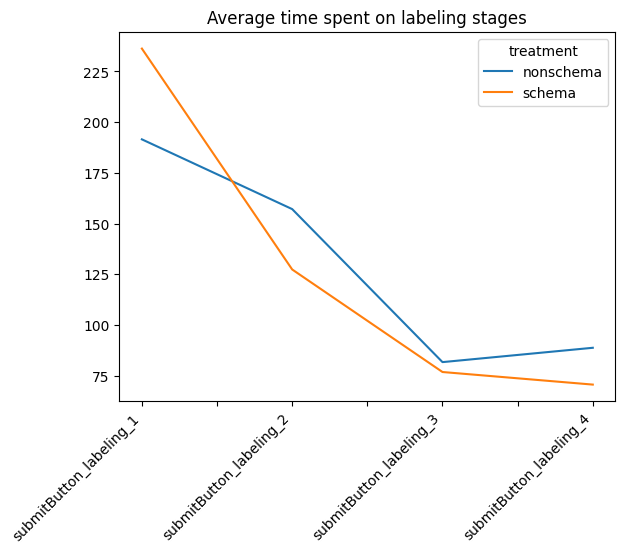

In [12]:
labeling_stages = sorted([k for k in submit_times.columns if "submitButton_labeling" in k])
submit_times[labeling_stages].groupby(level='treatment').mean().T.plot()
plt.title("Average time spent on labeling stages")
plt.xticks(rotation=45, ha='right')

In [13]:
submit_times[labeling_stages]

submitButton_labeling_1  submitButton_labeling_2  \
treatment game   player                                                     
nonschema 63E4P3 0                       204.787                  176.163   
                 1                       209.400                  167.755   
          DM261K 0                       142.203                  167.817   
                 1                       145.828                  169.427   
          34BR1P 1                       199.256                      NaN   
                 0                       186.908                      NaN   
          XX6T5Y 0                       270.536                      NaN   
                 1                       270.992                      NaN   
          VQP5V1 0                           NaN                      NaN   
                 1                           NaN                      NaN   
          FTM1KT 1                       137.072                  159.491   
                 0                       142.618                  166.017   
          Q6ZARX 1                       169.013                  137.765   
                 0                       169.290                  138.043   
          2XT15E 1                       216.425                  144.653   
                 0                       217.550                  144.783   
schema    RTYG0G 1                       264.287                   69.300   
                 0                       265.462                   70.473   
          RFMEFG 0                           NaN                      NaN   
                 1                           NaN                      NaN   
          Y15NND 1                       261.264                      NaN   
                 0                       260.710                      NaN   
          TKB9T5 1                           NaN                      NaN   
                 0                           NaN                      NaN   
          AYS7KJ 1                       205.446                  123.346   
                 0                       205.849                  126.706   
          ZN46AE 0                       175.821                      NaN   
                 1                       176.501                  180.819   
          TD1HQA 0                           NaN                      NaN   
                 1                           NaN                      NaN   
          2BY1T9 0                       274.259                  162.238   
                 1                       273.166                  159.261   

                         submitButton_labeling_3  submitButton_labeling_4  
treatment game   player                                                    
nonschema 63E4P3 0                           NaN                      NaN  
                 1                           NaN                   88.873  
          DM261K 0                        81.491                      NaN  
                 1                        82.131                      NaN  
          34BR1P 1                           NaN                      NaN  
                 0                           NaN                      NaN  
          XX6T5Y 0                           NaN                      NaN  
                 1                           NaN                      NaN  
          VQP5V1 0                           NaN                      NaN  
                 1                           NaN                      NaN  
          FTM1KT 1                           NaN                      NaN  
                 0                           NaN                      NaN  
          Q6ZARX 1                           NaN                      NaN  
                 0                           NaN                      NaN  
          2XT15E 1                           NaN                      NaN  
                 0                           NaN                      NaN  
schema    RTYG0G 1                    

TypeError: not all arguments converted during string formatting

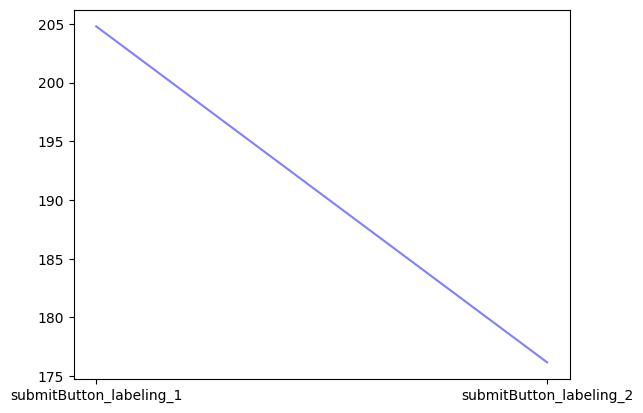

In [14]:
labeling_stages = sorted([label for label in submit_times.columns if 'labeling' in label])

for i, row in submit_times.iterrows():
    plt.plot(row[labeling_stages], c=('blue' if i[0] == 'nonschema' else 'red'), alpha=0.5, label=f"{i[0]}")
    if i[2] % 2 == 0:
        plt.annotate(
            f"{i[1]}", (len(labeling_stages)-1, row[labeling_stages[-1]]), 
            xycoords="data", ha='left', va='center'
            )

plt.xticks(rotation=90)
plt.ylim(0, 600)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xticks(range(len(labeling_stages)),[re.sub(r'submitButton_labeling_', 'Stage ', label) for label in labeling_stages])
plt.ylabel('Time to submit (s)')
plt.title("Time to coordinate labels")

Text(0.5, 1.0, 'Time to coordinate labels')

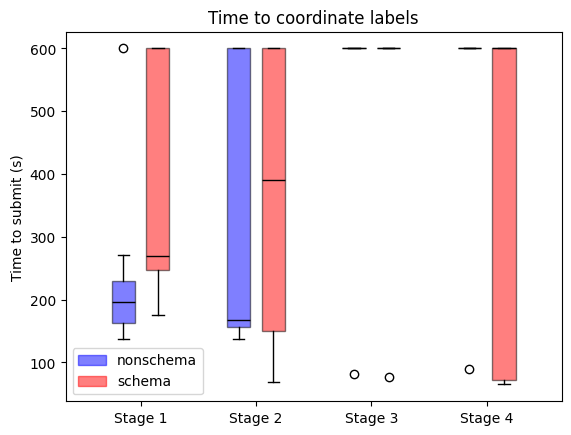

In [15]:
labeling_stages = sorted([label for label in submit_times.columns if 'labeling' in label])
labeling_times = submit_times[labeling_stages].fillna(600).groupby(level=["treatment", 'game']).min() # only use the min time from each group
plt.boxplot(labeling_times.loc["nonschema"], positions=np.arange(0, len(labeling_stages))-.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='blue', alpha=.5), medianprops=dict(color='black'))
plt.boxplot(labeling_times.loc["schema"], positions=np.arange(0, len(labeling_stages))+.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='red', alpha=.5), medianprops=dict(color='black'))
plt.xticks(range(len(labeling_stages)),[re.sub(r'submitButton_labeling_', 'Stage ', label) for label in labeling_stages])

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='blue', alpha=.5, label='nonschema')
red_patch = mpatches.Patch(color='red', alpha=.5, label='schema')

plt.legend(handles=[blue_patch, red_patch])
plt.ylabel('Time to submit (s)')
plt.title("Time to coordinate labels")


Text(0.5, 1.0, 'Time to recall labels')

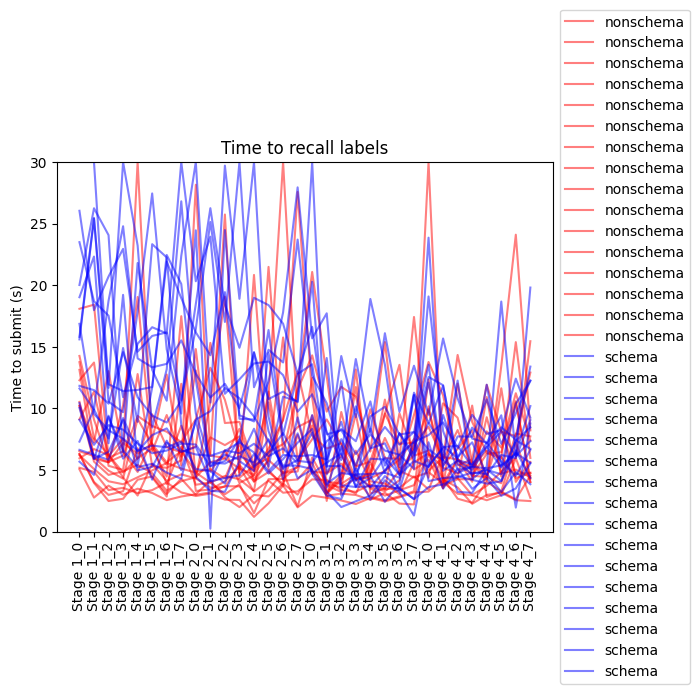

In [16]:
recall_stages = sorted([label for label in submit_times.columns if 'recall' in label])

for i, row in submit_times.iterrows():
    plt.plot(row[recall_stages].fillna(30), c=('blue' if i[0] == 'schema' else 'red'), alpha=0.5, label=f"{i[0]}")

plt.xticks(rotation=90)
plt.ylim(0, 30)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xticks(range(len(recall_stages)),[re.sub(r'submitButton_recall_', 'Stage ', label) for label in recall_stages])
plt.ylabel('Time to submit (s)')
plt.title("Time to recall labels")

Text(0.5, 1.0, 'Time to recall labels')

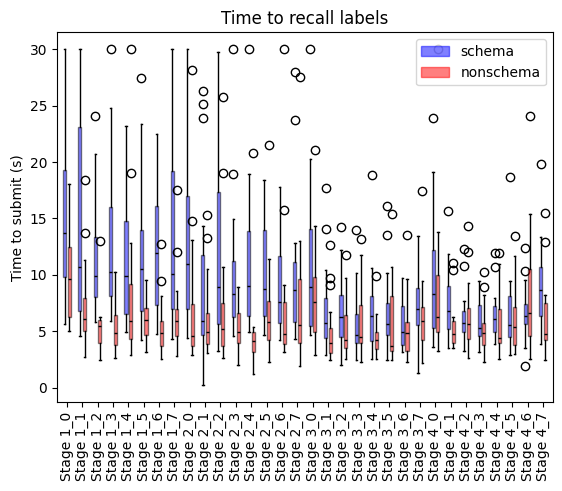

In [17]:
recall_stages = sorted([label for label in submit_times.columns if 'recall' in label])
recall_times = submit_times[recall_stages].fillna(30)
plt.boxplot(recall_times.loc["schema"], positions=np.arange(0, len(recall_stages))-.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='blue', alpha=.5), medianprops=dict(color='black'))
plt.boxplot(recall_times.loc["nonschema"], positions=np.arange(0, len(recall_stages))+.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='red', alpha=.5), medianprops=dict(color='black'))
plt.xticks(range(len(recall_stages)),[re.sub(r'submitButton_recall_', 'Stage ', label) for label in recall_stages], rotation=90)

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='blue', alpha=.5, label='schema')
red_patch = mpatches.Patch(color='red', alpha=.5, label='nonschema')

plt.legend(handles=[blue_patch, red_patch])
plt.ylabel('Time to submit (s)')
plt.title("Time to recall labels")

In [18]:
print(data[0]['prompts']['prompt_labeling_2']['value'])

Image 1: hair
Image 2:stoplight
Image 3:sherbert
Image 4:tree
Image 5:robot
Image 6:tall
Image 7:quad
Image 8:bus



In [19]:
data[0]['prompts'].keys()

dict_keys(['prompt_recall_1_0', 'prompt_recall_1_1', 'prompt_recall_1_2', 'prompt_recall_1_3', 'prompt_recall_1_4', 'prompt_recall_1_5', 'prompt_recall_1_6', 'prompt_recall_1_7', 'prompt_recall_2_0', 'prompt_recall_2_1', 'prompt_recall_2_2', 'prompt_recall_2_3', 'prompt_recall_2_4', 'prompt_recall_2_5', 'prompt_recall_2_6', 'prompt_recall_2_7', 'prompt_recall_3_0', 'prompt_recall_3_1', 'prompt_recall_3_2', 'prompt_recall_3_3', 'prompt_recall_3_4', 'prompt_recall_3_5', 'prompt_recall_3_6', 'prompt_recall_3_7', 'prompt_recall_4_0', 'prompt_recall_4_1', 'prompt_recall_4_2', 'prompt_recall_4_3', 'prompt_recall_4_4', 'prompt_recall_4_5', 'prompt_recall_4_6', 'prompt_recall_4_7', 'prompt_labeling_1', 'prompt_labeling_2', 'prompt_labeling_3', 'prompt_labeling_4'])

In [25]:
def extract_word(cell):
    return str(re.sub(r"\d", "", str(cell).replace("Image", "")).replace(":", "").replace("\n", ", ").strip().lower())

labels = pd.DataFrame([{f"stage_{i}": extract_word(row['prompts'][f'prompt_labeling_{i}']['value']) for i in [1, 2, 3, 4]} for row in data], index=index).T.xs('1', axis=1, level=2)
labels.to_clipboard()
labels['schema'].loc("stage_1")

ValueError: No axis named stage_1 for object type DataFrame

In [26]:
recall = pd.DataFrame([{f"stage_{i}_{j}": row['prompts'][f'prompt_recall_{i}_{j}']['value'].lower() if f'prompt_recall_{i}_{j}' in row['prompts'] else np.NAN for j in [0,1,2,3,4,5,6,7] for i in [1, 2, 3, 4]} for row in data], index=index).T.sort_index()
stage_numbers = [int(idx.split('_')[1]) for idx in recall.index]
recall.index = pd.MultiIndex.from_arrays([recall.index, stage_numbers], names=['original', 'stage'])

recall.to_clipboard()
recall['schema']

game            RTYG0G             RFMEFG              Y15NND            \
player               1      0           0          1        1         0   
original  stage                                                           
stage_1_0 1      pblbr  pblbr     private    private      may  february   
stage_1_1 1      oblbr  oblbr  brown feet      sarge  january   january   
stage_1_2 1       prbr   prbr     marchie        hut     july  february   
stage_1_3 1       pbly   pbly       sarge      sarge      may    august   
stage_1_4 1        ory    ory      sparky     sparky    april      june   
stage_1_5 1       obly   obly   beret man      hut\n  january     april   
stage_1_6 1       orbr   orbr      spunky     spunky    march      july   
stage_1_7 1        pry    pry         hut    marchie   august   january   
stage_2_0 2       prbr   prbr      center     center      one       one   
stage_2_1 2        ory    ory       mower      mower    seven     seven   
stage_2_2 2       orbr   orbr        silo       silo    eight     seven   
stage_2_3 2      oblbr  oblbr   fish eyes  fish eyes      two       two   
stage_2_4 2       pbly   pbly       piper      pipey     four       six   
stage_2_5 2        pry    pry     boombox   boom box     five      five   
stage_2_6 2      pblbr  pblbr       bowly      bowly      six       six   
stage_2_7 2       obly   obly        bino       bino    three       two   
stage_3_0 3       obly   obly       chair      chair    three      four   
stage_3_1 3       orbr   orbr      cactus     cactus     five      four   
stage_3_2 3        ory    pry        ears       ears    eight     eight   
stage_3_3 3        pry    pry        bird       bird     four      four   
stage_3_4 3      oblbr  oblbr         box        box      six       six   
stage_3_5 3      pblbr  pblbr        duck       duck      NaN     seven   
stage_3_6 3       pbly   pbly     rainbow    rainbow      one       one   
stage_3_7 3       prbr   prbr         NaN         et      two     three   
stage_4_0 4       pbly   pbly         bar        bar    seven     seven   
stage_4_1 4       pbly   pbly        book       book      two       two   
stage_4_2 4       orbr   orbr      orange       lego    three     three   
stage_4_3 4       orbr   orbr     tootsie    tootsie    eight     eight   
stage_4_4 4       orbr   orbr       plate      plate      one       one   
stage_4_5 4       orbr   orbr       short      short      six       six   
stage_4_6 4       pbly   pbly    two nose   two nose     five      five   
stage_4_7 4       pbly   pbly         owl        owl     four      four   

game                    TKB9T5                             AYS7KJ  \
player                       1                    0             1   
original  stage                                                     
stage_1_0 1       pulple brown         purple brown    right down   
stage_1_1 1          oranoge            black brown     down left   
stage_1_2 1          red brown         purple brown    down right   
stage_1_3 1      purple yellow  purple black yellow    right left   
stage_1_4 1      orange yellow           red yellow     left left   
stage_1_5 1       black yellow         orange black    left right   
stage_1_6 1       orange brown         orange brown     left down   
stage_1_7 1      purple yellow        purple yellow     down down   
stage_2_0 2          red brown            red brown  left leaning   
stage_2_1 2         red yellow           red yellow            rv   
stage_2_2 2          red brown            red brown            rv   
stage_2_3 2        black brown          black brown     brown leg   
stage_2_4 2       black yellow         black yellow   yellow feet   
stage_2_5 2         red yellow           red yellow    small feet   
stage_2_6 2        black brown          black brown    brown feet   
stage_2_7 2       black yellow         black yellow   yellow feet   
stage_3_0 3                NaN         black yellow          ta

In [119]:
match = recall.xs('1', axis=1, level=2) == recall.xs('0', axis=1, level=2)




In [27]:
# 2. For each column, for each stage, count entries that have at least one duplicate
def count_duplicates(group):
    # group is a Series for one column and one stage
    value_counts = group.value_counts()
    # Find values that appear more than once
    duplicates = value_counts[value_counts > 1].index
    # Count how many entries in the group are in the duplicates list
    return group.isin(duplicates).sum()

# Apply per column and per stage
duplicate_counts = recall.groupby(level='stage').agg(lambda col: col.groupby(level='stage').apply(count_duplicates))

# If you want a DataFrame with stages as rows and columns as in your original df:
# duplicate_counts = recall.groupby(level='stage').agg(lambda col: col.groupby(level='stage').apply(count_duplicates)).T

# Or, for a more standard shape:
# result = recall.groupby(level='stage').apply(lambda group: group.apply(count_duplicates))

# print(result)
duplicate_counts.to_clipboard()

In [28]:
duplicate_counts

treatment nonschema                                             ... schema     \
game         63E4P3    DM261K    34BR1P    XX6T5Y    VQP5V1     ... TKB9T5      
player            0  1      0  1      1  0      0  1      0  1  ...      1  0   
stage                                                           ...             
1                 2  2      2  2      2  4      2  4      4  4  ...      2  2   
2                 0  0      0  0      0  5      2  0      0  0  ...      8  8   
3                 0  0      0  0      4  3      4  4      0  0  ...      2  0   
4                 0  3      3  0      3  2      3  3      4  2  ...      2  0   

treatment                                          
game      AYS7KJ    ZN46AE    TD1HQA    2BY1T9     
player         1  0      0  1      0  1      0  1  
stage                                              
1              0  4      0  0      0  0      4  8  
2              4  0      0  0      2  4      0  5  
3              2  4      0  2      2  0      0  0  
4              0  0      8  8      2  2      0  0  

[4 rows x 32 columns]

In [120]:
stage_numbers = [int(idx.split('_')[1]) for idx in match.index]
df_grouped = match.copy()
df_grouped['stage'] = stage_numbers

# Now group by 'stage' and take the mean for each group
stage_means = df_grouped.groupby('stage').mean()
stage_means.to_clipboard()
stage_means

AttributeError: 'tuple' object has no attribute 'split'

In [117]:
recall.index

Index(['stage_1_0', 'stage_1_1', 'stage_1_2', 'stage_1_3', 'stage_1_4',
       'stage_1_5', 'stage_1_6', 'stage_1_7', 'stage_2_0', 'stage_2_1',
       'stage_2_2', 'stage_2_3', 'stage_2_4', 'stage_2_5', 'stage_2_6',
       'stage_2_7', 'stage_3_0', 'stage_3_1', 'stage_3_2', 'stage_3_3',
       'stage_3_4', 'stage_3_5', 'stage_3_6', 'stage_3_7', 'stage_4_0',
       'stage_4_1', 'stage_4_2', 'stage_4_3', 'stage_4_4', 'stage_4_5',
       'stage_4_6', 'stage_4_7'],
      dtype='object')

In [53]:
def extract_word(cell):
    return str(re.sub(r"\d", "", str(cell).replace("Image", "")).replace(":", "").strip().lower())
    # return str(cell).split(":")[1].strip().lower()

    # pattern = r"Image \d+:\s*(\w+\s)\s*"
    # match = re.search(pattern, str(cell), re.IGNORECASE)
    # return match.group(1) if match else cell

labels_collector = []
for row in data:
    row_labels = {}
    for key, d in row['prompts'].items():
        if 'labeling' in key:
            round = key.split('_')[1]
            print(key, round)
            round_labels = [extract_word(line) for line in d['value'].split("\n") if len(line.strip()) > 0]
            for i, label in enumerate(round_labels):
                row_labels[(round, i+1)] = label
    labels_collector.append(row_labels)
labels = pd.DataFrame(labels_collector, index=index).T
labels.index = pd.MultiIndex.from_tuples(labels.index, names=['round', 'image'])
labels = labels.T.groupby(level=["treatment", "game"]).first().T
labels

prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
prompt_labeling_2 labeling
prompt_labeling_3 labeling
prompt_labeling_4 labeling
prompt_labeling_1 labeling
p

treatment       nonschema                             schema            \
game                    0         1         2       3      4         5   
round    image                                                           
labeling 1       colorful  colorful      blue  circle            plate   
         2            bee      cube    purple    pink             book   
         3      stoplight    yellow    orange  yellow             lego   
         4         racoon      chip       red                      owl   
         5          robot       rat    yellow                 two nose   
         6            bug     black      pink                    short   
         7          gumby      pink    maroon  purple              bar   
         8           legs     brown  longlegs   brown          tootsie   

treatment                                
game                    6             7  
round    image                           
labeling 1      turquoise          blue  
         2           pink  short yellow  
         3           gold   tall yellow  
         4          robot    tall white  
         5          white   short white  
         6          black   short black  
         7         purple   tall purple  
         8          brown    tall brown

In [35]:
submit_times["submitButton_labeling"]

treatment  game  player
schema A   0     0         203.448
                 1         204.538
           1     2         194.571
                 3         195.668
           2     4          35.060
                 5          33.832
           3     6          19.810
                 7          23.939
schema B   4     8          40.343
                 9          38.543
           5     10         24.537
                 11         26.695
           6     12        321.778
                 13        323.269
           7     14        240.151
                 15        239.569
Name: submitButton_labeling, dtype: float64

In [44]:
labels.T

round                                                    labeling          \
image                                                           1       2   
treatment game                                                              
schema A  0                                          blue garland  cookie   
          1                                                   pry     plb   
          2                                                   orb     pby   
          3                                                                 
schema B  4                                                  test   njdfs   
          5                                                                 
          6                                             blue disc  shorty   
          7     chicken  snail  octopus  tower  robot  crab  c...    None   

round                                                                    \
image                     3          4            5      6            7   
treatment game                                                            
schema A  0     tall yellow  tall grey   short grey  demon  tall purple   
          1             ory        ply          olb    orb          prb   
          2             orb        pby          pby    orb          pby   
          3                     cactus       square  chips        mouse   
schema B  4                                                               
          5                                                               
          6            tree    rainbow  marshmallow  furby   paper clip   
          7            None       None         None   None         None   

round                      
image                   8  
treatment game             
schema A  0     long legs  
          1           oly  
          2           orb  
          3          None  
schema B  4                
          5                
          6     long legs  
          7          None

In [404]:
lengths = labels.applymap(lambda x: len(x))
lengths = lengths.groupby(level='round').mean().T
lengths

/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_52783/3109570211.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lengths = labels.applymap(lambda x: len(x))


round                1       2       3       4       5
treatment game                                        
nonschema 0      4.250  15.500  15.500   5.500   4.375
          1      5.500   5.375   4.625   5.625   5.250
          2      6.750   9.125   7.500   8.375   7.250
          3      6.125   7.500  15.875   5.375   4.625
          4      5.125   4.250   6.375   4.750   8.000
schema    5      4.000   4.000   4.000   7.875   6.375
          6     12.125  12.125  12.375  10.750   4.750
          7     18.000   8.500   7.125   8.750   8.375
          8      8.625   8.625   2.000   3.625   6.250
          9      5.000   5.000   5.000   8.000   6.750
          10    13.500  13.500  13.500  12.875  11.125
          11     5.000   4.125   1.000   2.000   3.000

Text(0.5, 1.0, 'Label Lengths')

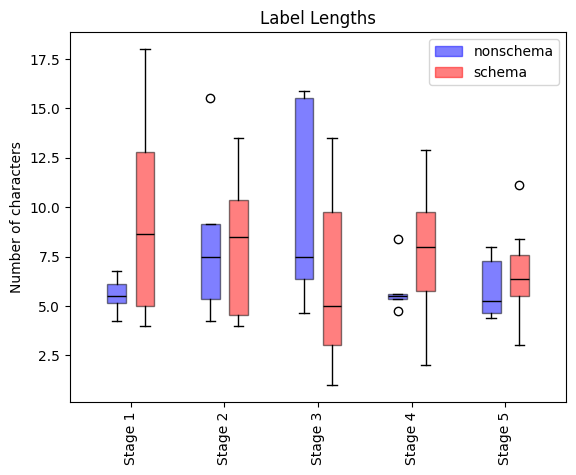

In [409]:

plt.boxplot(lengths.loc["nonschema"], positions=np.arange(0, len(labeling_stages))-.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='blue', alpha=.5), medianprops=dict(color='black'))
plt.boxplot(lengths.loc["schema"], positions=np.arange(0, len(labeling_stages))+.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='red', alpha=.5), medianprops=dict(color='black'))
plt.xticks(range(len(labeling_stages)),[re.sub(r'submitButton_labeling_', 'Stage ', label) for label in labeling_stages], rotation=90)

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='blue', alpha=.5, label='nonschema')
red_patch = mpatches.Patch(color='red', alpha=.5, label='schema')

plt.legend(handles=[blue_patch, red_patch])
plt.ylabel('Number of characters')
plt.title("Label Lengths")

In [330]:
labels.to_csv("labels.csv")

In [46]:
recall = pd.DataFrame([{key: d['value'] for key, d in row['prompts'].items() if 'recall' in key} for row in data], index=index).applymap(lambda x: str(x).lower().strip()).T
recall_index = pd.MultiIndex.from_tuples(pd.Series(recall.index).apply(lambda x: x.split("_")[2:]), names=["round", "stage"])
recall.index = recall_index
recall.sort_index(inplace=True)
recall.T


/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_77279/3088690296.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  recall = pd.DataFrame([{key: d['value'] for key, d in row['prompts'].items() if 'recall' in key} for row in data], index=index).applymap(lambda x: str(x).lower().strip()).T


round                                   1                         \
stage                                   0                      1   
treatment game player                                              
schema A  0    0              upside down          divided boots   
               1              brown shoes               red arms   
          1    2                      orb                    oly   
               3                      orb                    oly   
          2    4                      obb                    ory   
               5                      obb                    ory   
          3    6                      obb      orange red yellow   
               7       orange brown black  orange , read, yellow   
schema B  4    8                     fdsg                    nan   
               9                     sdgf                    nan   
          5    10                       2                      4   
               11                       2                      4   
          6    12                    orbb                   olry   
               13                    orby                    nan   
          7    14                    lbo1                    rro   
               15                    lbo2                   rrp1   

round                                                                \
stage                                                             2   
treatment game player                                                 
schema A  0    0                                           red arms   
               1                                           red arms   
          1    2                                                plb   
               3                                                plb   
          2    4                                                prb   
               5                                                prb   
          3    6       prb........just put the first letter of each   
               7                                   purple red brown   
schema B  4    8                                                nan   
               9                                                nan   
          5    10                                                 7   
               11                                                 7   
          6    12                                              plrb   
               13                                                or   
          7    14                                              rrp2   
               15                                              rro1   

round                                                    2                     \
stage                                    3               0           1      2   
treatment game player                                                           
schema A  0    0               purple head  rectangle legs  middle man  dumpy   
               1                 purpleead    lilac yellow   middleman  dumpy   
          1    2                       pry             ply         olb    oly   
               3                       pry             ply         olb    oly   
          2    4                       pby             pry         orb    ory   
               5                       pby             pry         orb    ory   
          3    6                       pby             pry         orb    ory   
               7       purple black yellow             prb         orb    ory   
schema B  4    8                       nan             nan         nan    nan   
               9                       nan             nan         nan    nan   
          5    10                        5               5           8      7   
               11                        5               5           8      7   
          6    12                     prby            plry        olrb   olry   
               13                     prby             plr   

In [47]:
submit_times["submitButton_labeling"]

treatment  game  player
schema A   0     0         203.448
                 1         204.538
           1     2         194.571
                 3         195.668
           2     4          35.060
                 5          33.832
           3     6          19.810
                 7          23.939
schema B   4     8          40.343
                 9          38.543
           5     10         24.537
                 11         26.695
           6     12        321.778
                 13        323.269
           7     14        240.151
                 15        239.569
Name: submitButton_labeling, dtype: float64

In [318]:
# group by game and check if the players within the game have matching values
matches = recall.T.groupby(level=['treatment', 'game']).apply(lambda x: x.nunique()==1).T
matches

treatment   nonschema                           schema                      \
game               0     1      2      3     4      5      6     7      8    
round stage                                                                  
1     1          True  True   True   True  True   True   True  True   True   
      2          True  True   True   True  True   True   True  True   True   
      3          True  True   True   True  True   True   True  True   True   
      4          True  True   True   True  True   True   True  True   True   
2     1          True  True  False   True  True   True   True  True   True   
      2          True  True   True   True  True   True   True  True   True   
      3          True  True   True   True  True   True   True  True   True   
      4          True  True   True  False  True   True   True  True   True   
3     1          True  True   True   True  True   True   True  True   True   
      2          True  True   True   True  True   True  False  True   True   
      3          True  True   True   True  True   True   True  True   True   
      4          True  True   True   True  True   True   True  True   True   
4     1          True  True   True   True  True   True   True  True   True   
      2          True  True   True  False  True   True   True  True   True   
      3          True  True   True   True  True   True   True  True   True   
      4          True  True   True   True  True   True   True  True   True   
5     1          True  True   True   True  True   True   True  True   True   
      2          True  True   True   True  True   True   True  True  False   
      3          True  True  False  False  True   True  False  True   True   
      4          True  True   True   True  True  False   True  True   True   

treatment                         
game            9      10     11  
round stage                       
1     1       True   True  False  
      2       True   True  False  
      3       True   True   True  
      4      False   True   True  
2     1       True   True   True  
      2       True   True   True  
      3       True   True   True  
      4       True   True   True  
3     1       True   True   True  
      2       True   True   True  
      3       True   True   True  
      4       True   True   True  
4     1       True   True   True  
      2       True   True   True  
      3       True  False   True  
      4       True   True   True  
5     1       True   True   True  
      2      False   True   True  
      3       True   True   True  
      4       True   True   True

In [331]:
match_counts = matches.groupby(level="round").sum()
match_counts.to_csv("match_counts.csv")
match_counts

treatment nonschema             schema                  
game             0  1  2  3  4      5  6  7  8  9  10 11
round                                                   
1                 4  4  4  4  4      4  4  4  4  3  4  2
2                 4  4  3  3  4      4  4  4  4  4  4  4
3                 4  4  4  4  4      4  3  4  4  4  4  4
4                 4  4  4  3  4      4  4  4  4  4  3  4
5                 4  4  3  3  4      3  3  4  3  3  4  4

Text(0.5, 1.0, 'Recall accuracy')

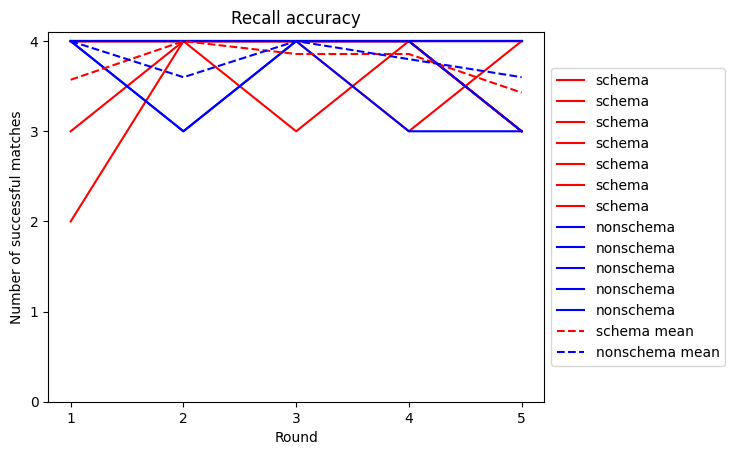

In [372]:
plt.plot(match_counts["schema"], c='red', label='schema')
plt.plot(match_counts["nonschema"], c='blue', label='nonschema')
plt.plot(match_counts["schema"].mean(axis=1), '--', c='red', label='schema mean')
plt.plot(match_counts["nonschema"].mean(axis=1), '--', c='blue', label='nonschema mean')
plt.ylim(0, 4.1)
plt.xlabel("Round")
plt.ylabel("Number of successful matches")
plt.yticks(range(5))
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))


plt.title("Recall accuracy")


Text(0.5, 1.0, 'Recall accuracy')

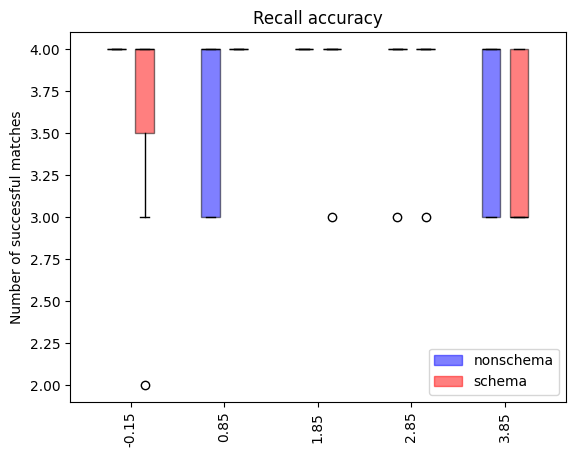

In [371]:
plt.boxplot(match_counts["nonschema"].T, positions=np.arange(0, len(labeling_stages))-.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='blue', alpha=.5), medianprops=dict(color='black'))
plt.boxplot(match_counts["schema"].T, positions=np.arange(0, len(labeling_stages))+.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='red', alpha=.5), medianprops=dict(color='black'))
plt.xticks(range(len(labeling_stages)), rotation=90)

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='blue', alpha=.5, label='nonschema')
red_patch = mpatches.Patch(color='red', alpha=.5, label='schema')

plt.legend(handles=[blue_patch, red_patch])
plt.ylabel('Number of successful matches')
plt.title("Recall accuracy")

In [370]:
match_counts["schema"]

game,5,6,7,8,9,10,11
round,,,,,,,
1,4,4,4,4,3,4,2
2,4,4,4,4,4,4,4
3,4,3,4,4,4,4,4
4,4,4,4,4,4,3,4
5,3,3,4,3,3,4,4


In [18]:
codes = [
    "SOBB",
    "SOBY",
    "SORB",
    "SORY",
    "SPBB",
    "SPBY",
    "SPRB",
    "SPRY",
]

np.random.shuffle(codes)
print(codes)

np.random.shuffle(codes)
print(codes)

np.random.shuffle(codes)
print(codes)

np.random.shuffle(codes)
print(codes)

['SPBB', 'SOBB', 'SPRB', 'SPBY', 'SORY', 'SOBY', 'SORB', 'SPRY']
['SPRB', 'SORY', 'SORB', 'SOBB', 'SPBY', 'SPRY', 'SPBB', 'SOBY']
['SOBY', 'SORB', 'SORY', 'SPRY', 'SOBB', 'SPBB', 'SPBY', 'SPRB']
['SORB', 'SORY', 'SPRY', 'SPBY', 'SPRB', 'SOBY', 'SPBB', 'SOBB']


In [19]:
codes = [
    "SORB1",
    "SORB2",
    "SORB3",
    "SORB4",
    "SPBY1",
    "SPBY2",
    "SPBY3",
    "SPBY4",
]

np.random.shuffle(codes)
print(codes)

['SPBY4', 'SPBY1', 'SORB2', 'SORB4', 'SORB1', 'SORB3', 'SPBY3', 'SPBY2']
